In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

In [8]:


# 1. Veriyi oku
df = pd.read_json("traffic_log.json", lines=True)

# 2. Oturum bazında grupla: (kaynak IP + kaynak port + hedef IP + hedef port + protokol)
df['session'] = df['src_ip'] + ":" + df['src_port'].astype(str) + "-" + df['dst_ip'] + ":" + df['dst_port'].astype(str) + "-" + df['protocol']

# 3. Gruplama işlemi
grouped = df.groupby("session").agg({
    "packet_length": ["sum", "count"],  # toplam veri ve paket sayısı
    "timestamp": ["min", "max"],  # oturum başlama ve bitiş zamanı
}).reset_index()

# 4. Gruplanmış veriyi göster
print(grouped.head())


                                       session packet_length        \
                                                         sum count   
0     108.157.60.69:443-192.168.0.35:57976-TCP          2066    11   
1     108.157.60.73:443-192.168.0.35:57974-TCP          1912    12   
2  108.177.119.188:5228-192.168.0.35:57924-TCP          3892    11   
3   142.250.187.164:443-192.168.0.35:62429-UDP          5719    10   
4     157.240.238.61:80-192.168.0.35:57893-TCP          4512    39   

                            timestamp                                      
                                  min                                 max  
0 2025-05-13 00:02:05.877461800+03:00    2025-05-13 00:02:15.197401+03:00  
1    2025-05-13 00:02:05.054920+03:00    2025-05-13 00:02:10.182753+03:00  
2 2025-05-13 00:00:38.066564700+03:00 2025-05-13 00:02:59.842270900+03:00  
3 2025-05-13 00:00:46.164570100+03:00 2025-05-13 00:00:46.243764700+03:00  
4 2025-05-13 00:00:54.352025500+03:00 2025-05-13 00:0

In [ ]:


# 1. Özellikler
grouped.columns = ['session', 'total_bytes', 'packet_count', 'session_start', 'session_end']
X = grouped[['total_bytes', 'packet_count']]

# 2. Normalizasyon
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Modeli eğit
model = IsolationForest(contamination=0.1, random_state=42) #kontaminasyon yüksekse model normale yüksek der
model.fit(X_scaled)

# 4. Modeli kaydet
joblib.dump(model, "session_anomaly_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

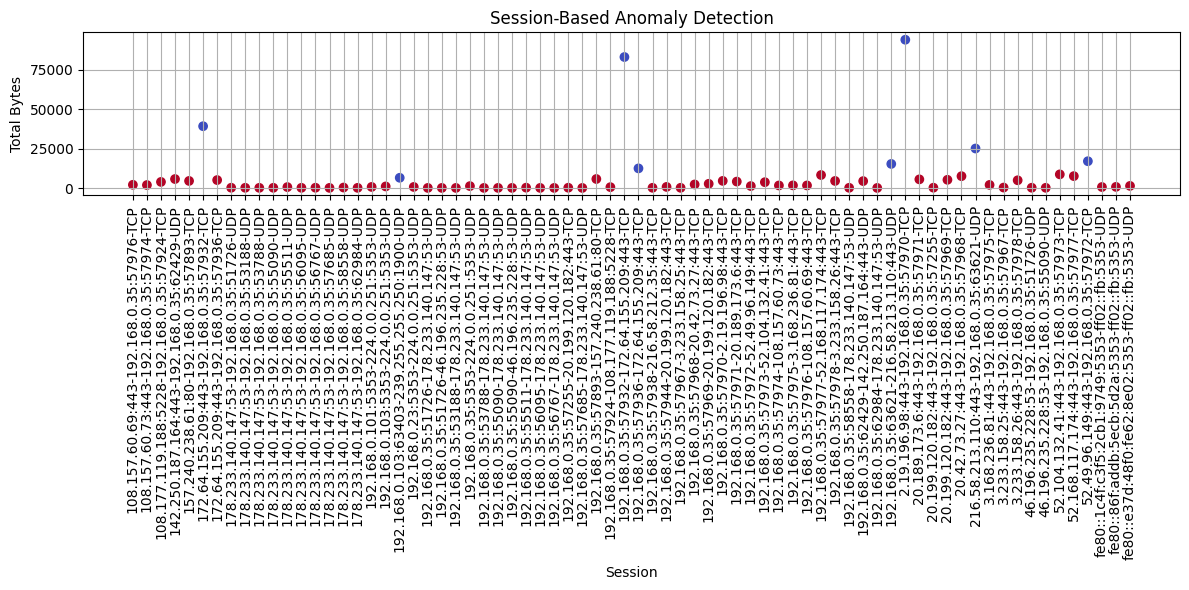

In [5]:


# 1. Anomali tahminleri
anomalies = model.predict(X_scaled)  # -1: anormal, 1: normal

# 2. Görselleştirme
grouped['anomaly'] = anomalies
plt.figure(figsize=(12, 6))
plt.scatter(grouped['session'], grouped['total_bytes'], c=grouped['anomaly'], cmap='coolwarm')
plt.xlabel('Session')
plt.ylabel('Total Bytes')
plt.title('Session-Based Anomaly Detection')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib

# 1. Veriyi oku
df = pd.read_json("traffic_log10.json", lines=True)

# 2. Oturum bazında grupla: (kaynak IP + kaynak port + hedef IP + hedef port + protokol)
df['session'] = df['src_ip'] + ":" + df['src_port'].astype(str) + "-" + df['dst_ip'] + ":" + df['dst_port'].astype(str) + "-" + df['protocol']

# 3. Gruplama işlemi
grouped = df.groupby("session").agg({
    "packet_length": ["sum", "count"],  # toplam veri ve paket sayısı
}).reset_index()

grouped.columns = ['session', 'total_bytes', 'packet_count']

# 4. Özellikleri al ve ölçeklendir
X = grouped[['total_bytes', 'packet_count']]
scaler = joblib.load("scaler.pkl")  # Önceki adımda kaydettiğimiz scaler'ı yükleyelim
X_scaled = scaler.transform(X)

# 5. Modeli yükle ve sapma skorunu al
model = joblib.load("session_anomaly_model.pkl")
scores = model.decision_function(X_scaled)

# 6. Skoru % formatına dönüştür
# Skorları [-1, 1] aralığında olduğu için, 0 ile 100 arasına dönüştürmemiz gerekiyor.
# Yüksek skor daha normal, düşük skor daha anormal demek.

# Dönüşüm: -1 -> 0%, 1 -> 100%
percentages = ((scores - min(scores)) / (max(scores) - min(scores))) * 100

# 7. Sapma sınıflandırmasını yap
def classify_anomaly(percentage):
    if percentage <= 30:
        return 'Düşük Sapma'
    elif percentage <= 70:
        return 'Orta Sapma'
    else:
        return 'Yüksek Sapma'

grouped['percentage'] = percentages
grouped['anomaly_class'] = grouped['percentage'].apply(classify_anomaly)

# 8. Sonuçları göster
print(grouped[['session', 'total_bytes', 'packet_count', 'percentage', 'anomaly_class']].head())


                                       session  total_bytes  packet_count  \
0     104.18.41.158:443-192.168.0.35:51164-UDP        59692            58   
1    104.225.98.129:443-192.168.0.35:58085-TCP         6418            13   
2  108.177.119.188:5228-192.168.0.35:57924-TCP         1592             5   
3     13.107.246.45:443-192.168.0.35:58060-TCP          357             5   
4     13.115.111.72:443-192.168.0.35:58095-TCP         5121            10   

   percentage anomaly_class  
0   21.629117   Düşük Sapma  
1   81.758123  Yüksek Sapma  
2   88.249019  Yüksek Sapma  
3   86.619238  Yüksek Sapma  
4   91.961005  Yüksek Sapma  
